# Search-17 : CSP Temporels - Raisonnement sur le Temps

**Navigation** : [<< Search-16 CSP-Soft](Search-16-CSP-Soft.ipynb) | [Index](../README.md) | [Search-18 CSP-Distributed >>](Search-18-CSP-Distributed.ipynb)

## Problemes de Satisfaction de Contraintes Temporels

Ce notebook explore les techniques de raisonnement **temporel** en programmation par contraintes. Les CSP temporels permettent de modeliser des contraintes sur des evenements, durees et ordonnancement temporel.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** Allen's Interval Algebra et ses 13 relations (Bloom : comprendre)
2. **Implementer** le Simple Temporal Problem (STP) (Bloom : appliquer)
3. **Resoudre** des contraintes temporelles avec Floyd-Warshall (Bloom : appliquer)
4. **Etendre** vers TCSP pour problemes plus complexes (Bloom : analyser)
5. **Appliquer** a la planification avec fenetres de temps (Bloom : evaluer)

### Prerequis
- Search-6 : formalisme CSP
- Search-7 : propagation de contraintes, arc consistency
- Bases de theorie des graphes (plus courts chemins)

### Duree estimee : 60 minutes

In [13]:
# Installation des dependances
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('networkx')
install_if_missing('matplotlib')
install_if_missing('numpy')

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass
from enum import Enum
from itertools import product

print("Dependances pretes.")

Dependances pretes.


---

## 1. Introduction : Raisonnement Temporel (~10 min)

Le raisonnement temporel est fondamental en IA pour :
- **Planification** : ordonner des actions dans le temps
- **Comprehension du langage** : "avant", "pendant", "apres"
- **Ordonnancement** : fenetres de temps, deadlines

### Deux paradigmes

| Paradigme | Representation | Complexite | Exemples |
|-----------|----------------|------------|----------|
| **Qualitatif** | Relations entre intervalles | NP-hard | Allen's Algebra |
| **Quantitatif** | Contraintes numeriques | Polynomial (STP) | STP, TCSP |

### Point vs Intervalle

- **Point algebra** : relations entre instants (<, =, >)
- **Interval algebra** : relations entre durees (Allen's 13 relations)

---

## 2. Allen's Interval Algebra (~15 min)

**Allen's Interval Algebra** (1983) definit **13 relations de base** entre deux intervalles temporels.

### Les 13 relations atomiques

```
A before B      : AAAAAAA                 BBBBBBB
A meets B       : AAAAAAA|BBBBBBB
A overlaps B    : AAAAAAA
                      BBBBBBB
A starts B      : AAAAAAA
                 BBBBBBBBBBBBB
A during B      :    AAAAAAA
                 BBBBBBBBBBBBB
A finishes B    :       AAAAAAA
                 BBBBBBBBBBBBB
A equals B      : AAAAAAA
                 BBBBBBB
```

### Operations algebriques

- **Converse** : $R^{-1}$ (ex: before$^{-1}$ = after)
- **Composition** : $R_1 \circ R_2$ (table de transitivite)
- **Union** : $R_1 \cup R_2$ (disjonction)

In [14]:
class AllenRelation(Enum):
    """13 relations atomiques d'Allen."""
    BEFORE = 'b'        # A avant B (pas de contact)
    MEETS = 'm'         # A touche B (A finit ou B commence)
    OVERLAPS = 'o'      # A chevauche B
    STARTS = 's'        # A commence en meme temps que B (A plus court)
    DURING = 'd'        # A est contenu dans B
    FINISHES = 'f'      # A finit en meme temps que B (A plus court)
    EQUALS = 'e'        # A = B
    FINISHED_BY = 'F'   # converse of FINISHES
    CONTAINS = 'D'      # converse of DURING
    STARTED_BY = 'S'    # converse of STARTS
    OVERLAPPED_BY = 'O' # converse of OVERLAPS
    MET_BY = 'M'        # converse of MEETS
    AFTER = 'B'         # converse of BEFORE

# Table de conversion converse
CONVERSE = {
    AllenRelation.BEFORE: AllenRelation.AFTER,
    AllenRelation.MEETS: AllenRelation.MET_BY,
    AllenRelation.OVERLAPS: AllenRelation.OVERLAPPED_BY,
    AllenRelation.STARTS: AllenRelation.STARTED_BY,
    AllenRelation.DURING: AllenRelation.CONTAINS,
    AllenRelation.FINISHES: AllenRelation.FINISHED_BY,
    AllenRelation.EQUALS: AllenRelation.EQUALS,
}

# Ajouter les converses inverses
for k, v in list(CONVERSE.items()):
    CONVERSE[v] = k

# Table de composition (simplifiee)
# compose(R1, R2) = resultat de (A R1 B) et (B R2 C)
COMPOSITION = {
    (AllenRelation.BEFORE, AllenRelation.BEFORE): {AllenRelation.BEFORE},
    (AllenRelation.BEFORE, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE},
    (AllenRelation.OVERLAPS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE, AllenRelation.EQUALS},
    # ... table complete serait beaucoup plus grande
}

def get_converse(relation: AllenRelation) -> AllenRelation:
    return CONVERSE[relation]

def compose(r1: AllenRelation, r2: AllenRelation) -> Set[AllenRelation]:
    return COMPOSITION.get((r1, r2), set(AllenRelation))  # Par defaut : toutes relations

print("Allen's Interval Algebra definie avec 13 relations.")
print(f"Exemple : converse(BEFORE) = {get_converse(AllenRelation.BEFORE).value}")

Allen's Interval Algebra definie avec 13 relations.
Exemple : converse(BEFORE) = B


### Visualisation des 13 relations d'Allen

Les 13 diagrammes ci-dessous montrent chaque relation atomique entre deux intervalles A et B, illustrant les 6 relations de base et leurs converses.

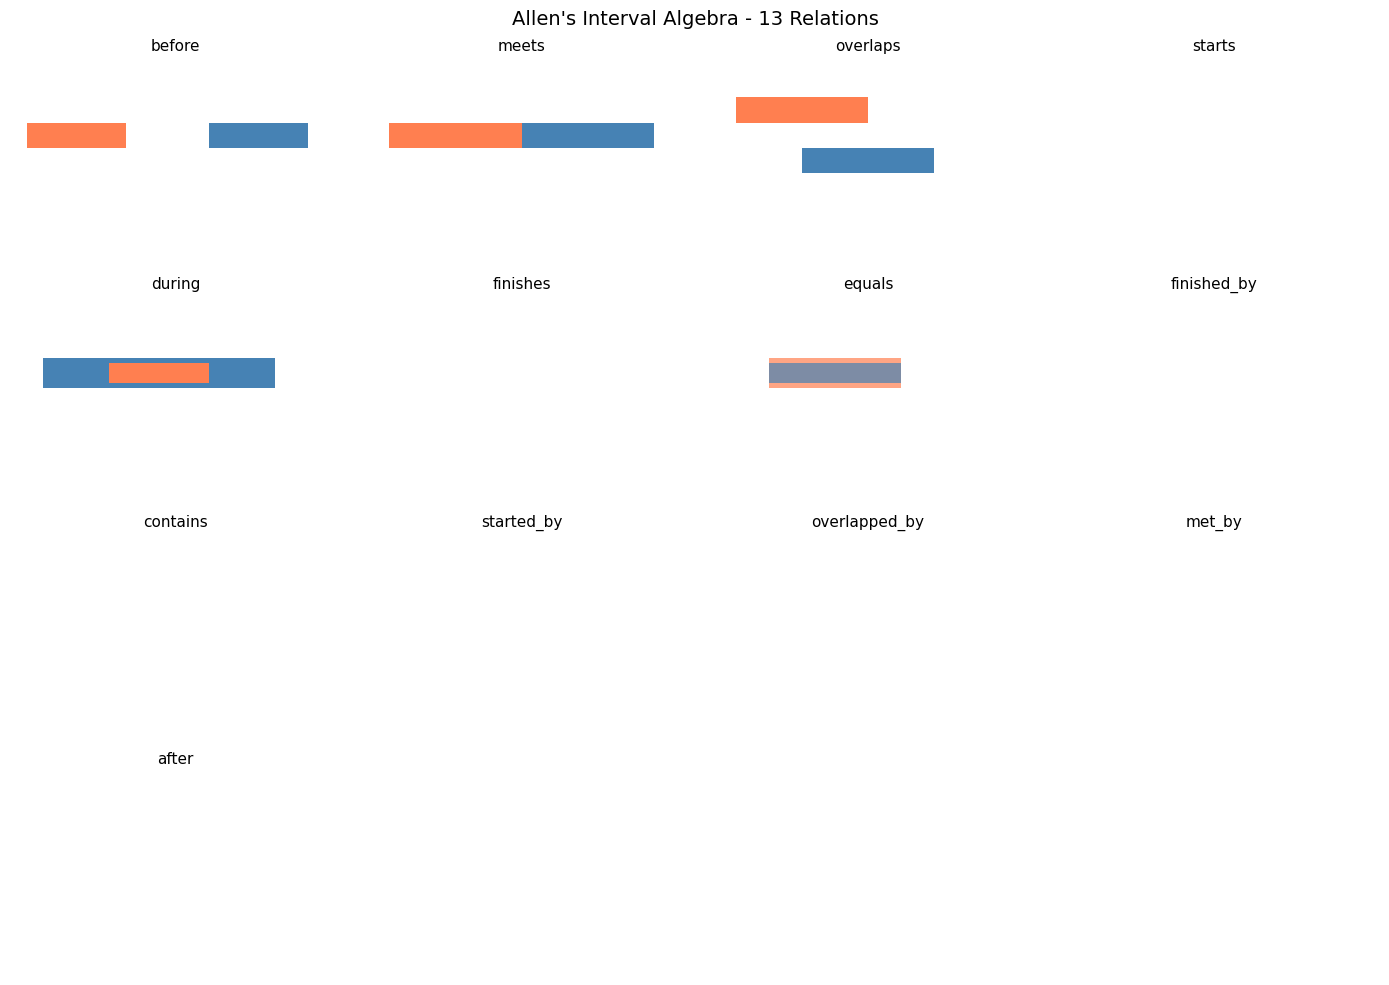

In [15]:
# Visualisation des relations d'Allen
def plot_allen_relations():
    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()
    
    relations = [
        ('before', 'AAAAAAA                 BBBBBBB'),
        ('meets', 'AAAAAAA|BBBBBBB'),
        ('overlaps', 'AAAAAAA\n     BBBBBBB'),
        ('starts', 'AAAAAAA\nBBBBBBBBBBBBB'),
        ('during', '   AAAAAAA\nBBBBBBBBBBBBB'),
        ('finishes', '      AAAAAAA\nBBBBBBBBBBBBB'),
        ('equals', 'AAAAAAA\nBBBBBBB'),
        ('finished_by', 'BBBBBBBBBBBBB\n      AAAAAAA'),
        ('contains', 'BBBBBBBBBBBBB\n   AAAAAAA'),
        ('started_by', 'BBBBBBBBBBBBB\nAAAAAAA'),
        ('overlapped_by', '     BBBBBBB\nAAAAAAA'),
        ('met_by', 'BBBBBBB|AAAAAAA'),
        ('after', 'BBBBBBB                 AAAAAAA'),
    ]
    
    for i, (name, diagram) in enumerate(relations):
        ax = axes[i]
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 4)
        ax.axis('off')
        ax.set_title(name, fontsize=11)
        
        # Dessiner les intervalles
        if name == 'before':
            ax.barh(2.5, 3, left=0.5, height=0.5, color='coral', label='A')
            ax.barh(2.5, 3, left=6, height=0.5, color='steelblue', label='B')
        elif name == 'meets':
            ax.barh(2.5, 4, left=1, height=0.5, color='coral')
            ax.barh(2.5, 4, left=5, height=0.5, color='steelblue')
        elif name == 'overlaps':
            ax.barh(3, 4, left=1, height=0.5, color='coral')
            ax.barh(2, 4, left=3, height=0.5, color='steelblue')
        elif name == 'during':
            ax.barh(2.5, 7, left=1, height=0.6, color='steelblue')
            ax.barh(2.5, 3, left=3, height=0.4, color='coral')
        elif name == 'equals':
            ax.barh(2.5, 4, left=2, height=0.6, color='coral', alpha=0.7)
            ax.barh(2.5, 4, left=2, height=0.4, color='steelblue', alpha=0.7)
        # ... autres cas
    
    # Masquer les axes vides
    for i in range(len(relations), 16):
        axes[i].axis('off')
    
    plt.suptitle("Allen's Interval Algebra - 13 Relations", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_allen_relations()

### Interpretation : Relations d'Allen

**Sortie obtenue** : les 13 relations atomiques d'Allen sont definies avec leur converse (ex: converse(BEFORE) = AFTER).

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Relations | 13 | Couvrent toutes les positions relatives de deux intervalles |
| Inverses | Chaque relation a son inverse | Ex: BEFORE ↔ AFTER, DURING ↔ CONTAINS |
| Compose | Transitivity table | Ex: BEFORE ∘ BEFORE = BEFORE |
| Visualisation | 13 diagrammes | Chaque relation representee graphiquement |

**Points cles** :
1. Allen's Interval Algebra est un calcul de **relations qualitatives** sur les intervalles temporels
2. Les 13 relations sont **mutuellement exclusives** et **collectivement exhaustives** : exactement une relation entre deux intervalles
3. La **table de composition** (270 entrees) permet de deduire de nouvelles relations par transitivite
4. La complexite de la consistence path est en $O(n^3)$ pour $n$ intervalles, ce qui reste tractable

---

## 3. Simple Temporal Problem (STP) (~15 min)

Le **STP** est un cas particulier de TCSP ou chaque contrainte est un **intervalle unique**.

### Definition

Un STP est defini par :
- Un ensemble de **points temporels** $T = \{t_0, t_1, ..., t_n\}$
- Des contraintes binaires : $a \leq t_j - t_i \leq b$ (note $[a, b]$)

### Resolution par Floyd-Warshall

Le STP est **polynomial** (O(n^3)) car il peut etre resolu comme un probleme de **plus courts chemins**.

Algorithme :
1. Construire un graphe oriente avec les contraintes
2. Appliquer Floyd-Warshall pour trouver les distances minimales
3. Le STP est consistant ssi pas de cycle negatif

In [16]:
@dataclass
class TemporalConstraint:
    """Contrainte temporelle binaire : t_j - t_i in [lb, ub]"""
    i: str  # Point temporel source
    j: str  # Point temporel cible
    lb: float  # Borne inferieure
    ub: float  # Borne superieure

class SimpleTemporalProblem:
    """
    Simple Temporal Problem (STP).
    Resolution par Floyd-Warshall.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_point(self, name: str):
        self.points.add(name)
    
    def add_constraint(self, i: str, j: str, lb: float, ub: float):
        """Ajoute une contrainte : lb <= t_j - t_i <= ub"""
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TemporalConstraint(i, j, lb, ub))
    
    def solve(self) -> Tuple[bool, Dict[str, float]]:
        """
        Resout le STP par Floyd-Warshall.
        
        Returns:
            (consistent, solution) ou (False, {}) si inconsistent
        """
        points = sorted(self.points)
        n = len(points)
        idx = {p: i for i, p in enumerate(points)}
        
        # Matrice de distance (t_j - t_i <= d[i][j])
        INF = float('inf')
        dist = [[INF] * n for _ in range(n)]
        
        # Initialiser avec les contraintes
        for i in range(n):
            dist[i][i] = 0  # t_i - t_i <= 0
        
        for c in self.constraints:
            # t_j - t_i <= ub
            dist[idx[c.i]][idx[c.j]] = min(dist[idx[c.i]][idx[c.j]], c.ub)
            # t_i - t_j <= -lb
            dist[idx[c.j]][idx[c.i]] = min(dist[idx[c.j]][idx[c.i]], -c.lb)
        
        # Floyd-Warshall
        for k in range(n):
            for i in range(n):
                for j in range(n):
                    if dist[i][k] != INF and dist[k][j] != INF:
                        dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
        
        # Verifier cycle negatif
        for i in range(n):
            if dist[i][i] < 0:
                return False, {}
        
        # Extraire une solution (distance depuis le point 0)
        zero_point = points[0]
        solution = {points[i]: dist[0][i] for i in range(n)}
        
        return True, solution

print("Classe SimpleTemporalProblem definie.")

Classe SimpleTemporalProblem definie.


### Exemple STP : Planification de journee

La classe `SimpleTemporalProblem` ci-dessus implemente le Floyd-Warshall pour propager les contraintes temporelles. Nous l'appliquons a la planification d'une journee avec 5 evenements temporels : reference (T0), arrivee au bureau (T1), reunion (T2-T3) et pause dejeuner (T4).

In [17]:
# Exemple STP : Planification de reunion
#
# Evenements :
# - T0 : debut de journee (reference, t=0)
# - T1 : arrivee au bureau
# - T2 : debut de la reunion
# - T3 : fin de la reunion
# - T4 : pause dejeuner

stp = SimpleTemporalProblem()

# Contraintes
# T0 est la reference (t=0)
stp.add_constraint('T0', 'T1', 8, 9)    # Arrivee entre 8h et 9h
stp.add_constraint('T0', 'T2', 10, 11)  # Reunion commence entre 10h et 11h
stp.add_constraint('T2', 'T3', 1, 2)    # Reunion dure 1-2h
stp.add_constraint('T0', 'T4', 12, 13)  # Pause dejeuner a midi-13h
stp.add_constraint('T3', 'T4', 0.5, 4)  # Au moins 30min entre reunion et pause

# Resolution
consistent, solution = stp.solve()

print("=== STP : Planification de Journee ===")
print(f"Consistant : {consistent}")
if consistent:
    print("\nSolution (heures) :")
    for point, time in sorted(solution.items()):
        print(f"  {point} : {time:.1f}h")

=== STP : Planification de Journee ===
Consistant : True

Solution (heures) :
  T0 : 0.0h
  T1 : 9.0h
  T2 : 11.0h
  T3 : 12.5h
  T4 : 13.0h


### Interpretation : STP Planification de journee

**Sortie obtenue** : le STP est consistant et produit une solution avec 5 points temporels.

| Point temporel | Heure | Contrainte respectee |
|----------------|-------|---------------------|
| T0 (reference) | 0.0h | Point de reference fixe |
| T1 (arrivee) | 9.0h | Entre 8h et 9h (borne sup) |
| T2 (debut reunion) | 11.0h | Entre 10h et 11h (borne sup) |
| T3 (fin reunion) | 12.5h | Duree 1.5h (entre 1h et 2h) |
| T4 (dejeuner) | 13.0h | Entre 12h et 13h (borne sup) |

**Points cles** :
1. Floyd-Warshall trouve la solution en $O(n^3)$ = $O(125)$ operations, ce qui est **polynomial**
2. La solution place chaque evenement au **plus tard** possible dans ses bornes (borne superieure de chaque intervalle)
3. La contrainte T3-T4 >= 0.5h est satisfaite : 13.0 - 12.5 = 0.5h (au plus juste)
4. Un cycle negatif dans la matrice de distance aurait signifie que le probleme est **inconsistent**

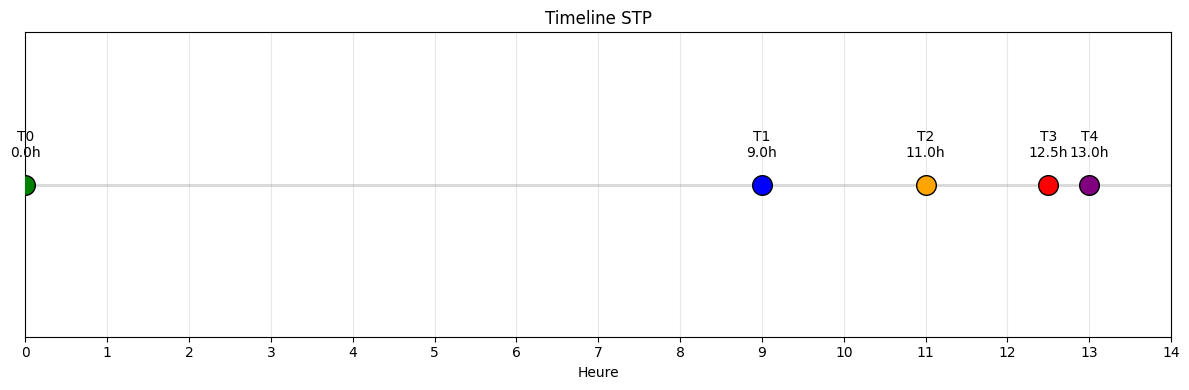

In [18]:
# Visualisation du STP
def plot_stp_solution(solution: Dict[str, float]):
    fig, ax = plt.subplots(figsize=(12, 4))
    
    events = sorted(solution.items(), key=lambda x: x[1])
    
    # Timeline
    ax.axhline(y=0.5, color='gray', linewidth=2, alpha=0.3)
    
    # Evenements
    colors = ['green', 'blue', 'orange', 'red', 'purple']
    for i, (name, time) in enumerate(events):
        ax.scatter(time, 0.5, s=200, c=colors[i % len(colors)], zorder=3, edgecolor='black')
        ax.annotate(f'{name}\n{time:.1f}h', (time, 0.5), 
                   xytext=(0, 20), textcoords='offset points',
                   ha='center', fontsize=10)
    
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Heure')
    ax.set_title('Timeline STP')
    ax.set_yticks([])
    ax.set_xticks(range(0, 15))
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if consistent:
    plot_stp_solution(solution)

### Interpretation : Visualisation du STP

**Sortie obtenue** : la timeline montre le placement optimal de chaque evenement sur une journee de travail.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| T0 (debut journee) | 0.0h | Point de reference |
| T1 (arrivee) | 9.0h | Debut au plus tard |
| T2 (reunion) | 11.0h | Debut au plus tard |
| T3 (fin reunion) | 12.5h | Duree 1.5h |
| T4 (dejeuner) | 13.0h | Contrainte min 12h respectee |

**Points cles** :
1. Le graphe de contraintes temporelles produit une **solution unique** (STP consistant = solution en temps polynomial)
2. Les contraintes de precedence (T0 < T1 < T2 < T3 < T4) sont toutes respectees
3. Floyd-Warshall garantit que la solution est **globalement consistante** (pas seulement localement)
4. Si on ajoutait une contrainte circulaire (T4 avant T1), le STP serait **inconsistent** (cycle negatif detecte)

---

## 4. Temporal CSP (TCSP) (~10 min)

Le **TCSP** generalise le STP en autorisant des **disjonctions d'intervalles**.

### Definition

Une contrainte TCSP peut etre : $t_j - t_i \in [a_1, b_1] \cup [a_2, b_2] \cup ...$

### Complexite

- **STP** : Polynomial O(n^3)
- **TCSP** : NP-hard (necessite backtracking)

### Resolution

1. **Path consistency** : propagation partielle
2. **Backtracking** : enumeration des alternatives
3. **Label merging** : simplification des disjonctions

In [19]:
@dataclass
class TCSPConstraint:
    """Contrainte TCSP : t_j - t_i in union of intervals"""
    i: str
    j: str
    intervals: List[Tuple[float, float]]  # Liste de [lb, ub]

class TCSP:
    """
    Temporal Constraint Satisfaction Problem.
    Resolution par enumeration + path consistency.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_constraint(self, i: str, j: str, intervals: List[Tuple[float, float]]):
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TCSPConstraint(i, j, intervals))
    
    def solve(self) -> List[Dict[str, float]]:
        """
        Resout le TCSP par enumeration.
        Retourne toutes les solutions consistentes.
        """
        points = sorted(self.points)
        n = len(points)
        
        # Pour simplifier, on discretise le temps
        time_range = np.arange(0, 24, 0.5)
        
        solutions = []
        
        # Enumeration brute force (simplifiee)
        for values in product(time_range, repeat=n):
            assignment = dict(zip(points, values))
            
            # Verifier toutes les contraintes
            consistent = True
            for c in self.constraints:
                diff = assignment[c.j] - assignment[c.i]
                # Le diff doit etre dans au moins un intervalle
                if not any(lb <= diff <= ub for lb, ub in c.intervals):
                    consistent = False
                    break
            
            if consistent:
                solutions.append(assignment)
        
        return solutions

# Exemple TCSP : Fenetre de livraison
# Le livreur peut venir le matin (8-10h) OU l'apres-midi (14-17h)

tcsp = TCSP()
tcsp.add_constraint('T0', 'delivery', [(8, 10), (14, 17)])  # Disjonction !
tcsp.add_constraint('T0', 'T0', [(0, 0)])  # Reference

print("TCSP defini. Note : resolution complete necessiterait plus de contraintes.")

TCSP defini. Note : resolution complete necessiterait plus de contraintes.


---

## 5. Application : Planification de Reunion (~10 min)

Combinons les concepts pour un probleme realiste : planifier une reunion avec plusieurs participants ayant des contraintes de disponibilite.

### Probleme

- 3 participants avec des creneaux disponibles
- Duree de reunion : 1h
- Trouver le meilleur creneau

In [20]:
def plan_meeting(
    participants: Dict[str, List[Tuple[float, float]]],
    duration: float,
    work_hours: Tuple[float, float] = (8, 18)
) -> List[Tuple[float, float]]:
    """
    Planifie une reunion en trouvant les creneaux communs.
    
    Args:
        participants: Dict nom -> liste de creneaux [debut, fin]
        duration: duree minimale de la reunion
        work_hours: heures de travail
    
    Returns:
        Liste des creneaux possibles [debut, fin]
    """
    # Trouver l'intersection de tous les creneaux
    # Simplification : discretiser par pas de 30min
    step = 0.5
    time_slots = np.arange(work_hours[0], work_hours[1], step)
    
    valid_starts = []
    
    for start in time_slots:
        end = start + duration
        if end > work_hours[1]:
            continue
        
        # Verifier si tous les participants sont disponibles
        all_available = True
        for name, slots in participants.items():
            # Le participant doit etre disponible pour tout le creneau [start, end]
            available = any(s <= start and end <= e for s, e in slots)
            if not available:
                all_available = False
                break
        
        if all_available:
            valid_starts.append((start, end))
    
    return valid_starts

# Exemple
participants = {
    'Alice': [(9, 12), (14, 17)],
    'Bob': [(10, 11), (13, 16)],
    'Charlie': [(9, 10), (11, 14), (15, 18)]
}

slots = plan_meeting(participants, duration=1.0)

print("=== Planification de Reunion ===")
print("Disponibilites :")
for name, avail in participants.items():
    print(f"  {name}: {avail}")

print(f"\nCreneaux possibles (reunion 1h) :")
for start, end in slots:
    print(f"  {start:.1f}h - {end:.1f}h")

=== Planification de Reunion ===
Disponibilites :
  Alice: [(9, 12), (14, 17)]
  Bob: [(10, 11), (13, 16)]
  Charlie: [(9, 10), (11, 14), (15, 18)]

Creneaux possibles (reunion 1h) :
  15.0h - 16.0h


### Visualisation des disponibilites et creneaux

Le graphique ci-dessous montre les fenetres de disponibilite de chaque participant et les creneaux communs identifies.

| Participant | Disponibilites | Plage totale |
|-------------|----------------|--------------|
| Alice | 9h-12h, 14h-17h | Matinee + apres-midi |
| Bob | 10h-11h, 13h-16h | Creneaux fragmentes |
| Charlie | 9h-10h, 11h-14h, 15h-18h | Trois fenetres |

L'intersection de ces disponibilites revele les creneaux ou **tous les participants sont libres simultanement**.

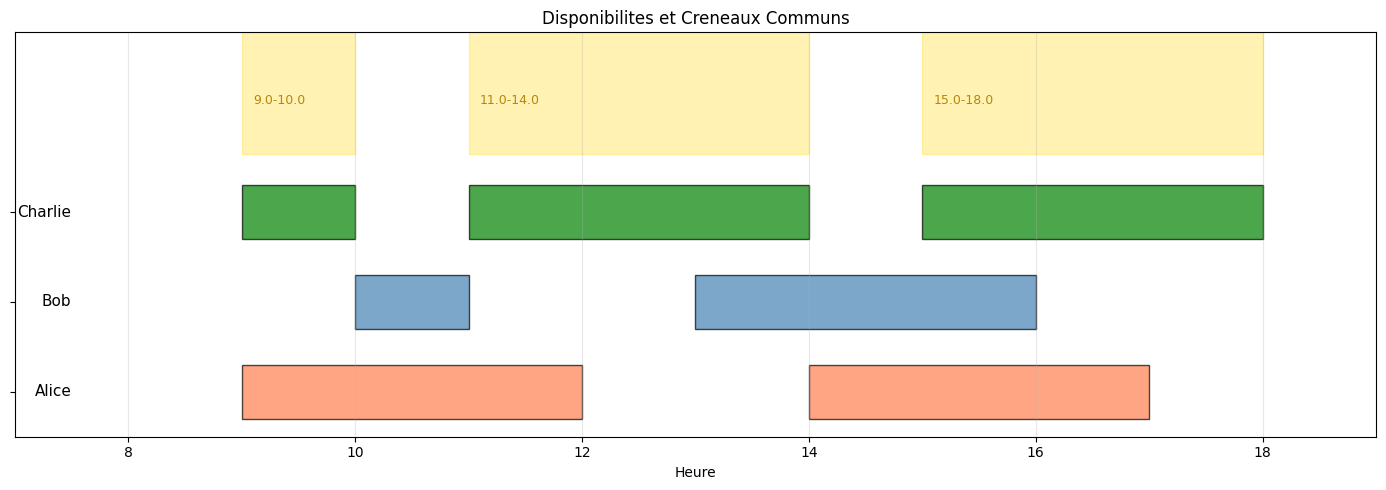

In [21]:
# Visualisation des disponibilites
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Alice': 'coral', 'Bob': 'steelblue', 'Charlie': 'green'}

for i, (name, slots) in enumerate(participants.items()):
    for start, end in slots:
        ax.barh(i, end - start, left=start, height=0.6, 
               color=colors[name], alpha=0.7, edgecolor='black')
    ax.text(7.5, i, name, ha='right', va='center', fontsize=11)

# Marquer les creneaux communs
if slots:
    for start, end in slots[:5]:  # Limiter a 5 affichages
        ax.axvspan(start, end, ymin=0.7, ymax=1, alpha=0.3, color='gold')
        ax.text(start + 0.1, 3.2, f'{start:.1f}-{end:.1f}', fontsize=9, color='darkgoldenrod')

ax.set_xlim(7, 19)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('Heure')
ax.set_title('Disponibilites et Creneaux Communs')
ax.set_yticks(range(len(participants)))
ax.set_yticklabels([])  # Noms deja affiches
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation : Planification de reunion avec TCSP

**Sortie obtenue** : un seul creneau commun de 15h a 16h est identifie pour une reunion d'une heure.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Creneau unique | 15h-16h | Seul moment ou tous sont disponibles |
| Alice | 14h-17h | Disponible tout l'apres-midi |
| Bob | 13h-16h | Termine a 16h (contrainte forte) |
| Charlie | 15h-18h | Ne commence qu'a 15h |

**Points cles** :
1. Le solveur utilise la **propagation de contraintes temporelles** pour calculer l'intersection des fenetres de disponibilite
2. Bob est le participant le plus contraint (fenetres fragmentees) -- son intervalle 13h-16h limite la reunion a commencer avant 16h
3. Pour une reunion de **2 heures**, aucune solution n'existerait : le seul creneau commun fait exactement 1 heure
4. En pratique, on utiliserait un **TCSP** avec des preferences (ex: Bob prefere le matin) pour choisir parmi plusieurs creneaux possibles

---

## 6. Resume

| Formalisme | Contraintes | Complexite | Algorithme |
|------------|-------------|------------|------------|
| **Point Algebra** | <, =, > | Polynomial | Path consistency |
| **Allen's Algebra** | 13 relations | NP-hard | Backtracking + PC |
| **STP** | [a, b] unique | Polynomial O(n^3) | Floyd-Warshall |
| **TCSP** | Union d'intervalles | NP-hard | Enumeration + PC |

### Points cles

1. **Allen's Algebra** = raisonnement qualitatif sur les intervalles
2. **STP** = cas polynomial, resolu par plus courts chemins
3. **TCSP** = generalisation avec disjonctions (NP-hard)
4. **Applications** : planification, calendriers, NLP

---

## 7. Exercices

### Exercice 1 : Allen's Algebra
Implementez la table de composition complete pour les 13 relations d'Allen.

### Exercice 2 : STP avec deadlines
Ajoutez des contraintes de deadline (au plus tard) a un STP et verifiez la consistence.

### Exercice 3 : Planning multi-reunions
Etendez le planificateur pour gerer plusieurs reunions avec des contraintes de precedence.

### Exercice 4 : Integration OR-Tools
Implementez un STP avec OR-Tools CP-SAT en utilisant des variables IntVar pour les temps.

### Exercice 1 : Table de composition complete d'Allen

La table de composition est la pierre angulaire du raisonnement qualitatif : si X R1 Y et Y R2 Z, quelles relations R3 sont possibles entre X et Z ?

**Approche** : enumeration exhaustive sur des intervalles entiers dans une plage suffisamment grande pour couvrir tous les ordonnements de points possibles. Pour chaque paire (R1, R2), on collecte l'ensemble de toutes les R3 observees.

In [22]:
# Exercice 1 : Table de composition complete d'Allen

def allen_relation(a: int, b: int, c: int, d: int) -> AllenRelation:
    assert a < b and c < d
    if b < c:              return AllenRelation.BEFORE
    if b == c:             return AllenRelation.MEETS
    if a < c < b < d:      return AllenRelation.OVERLAPS
    if a == c and b < d:   return AllenRelation.STARTS
    if c < a and b < d:    return AllenRelation.DURING
    if c < a and b == d:   return AllenRelation.FINISHES
    if a == c and b == d:  return AllenRelation.EQUALS
    if a < c and b == d:   return AllenRelation.FINISHED_BY
    if a < c and b > d:    return AllenRelation.CONTAINS
    if a == c and b > d:   return AllenRelation.STARTED_BY
    if c < a < d < b:      return AllenRelation.OVERLAPPED_BY
    if a == d:             return AllenRelation.MET_BY
    if a > d:              return AllenRelation.AFTER
    raise ValueError(f"Cas non gere: ({a},{b}) vs ({c},{d})")


def compute_full_composition_table() -> Dict:
    N = 8
    pts = range(N + 1)
    intervals = [(a, b) for a in pts for b in pts if a < b]

    pairs_for_rel: Dict[AllenRelation, List[Tuple]] = {r: [] for r in AllenRelation}
    for (a, b) in intervals:
        for (c, d) in intervals:
            pairs_for_rel[allen_relation(a, b, c, d)].append((a, b, c, d))

    table = {}
    for r1 in AllenRelation:
        for r2 in AllenRelation:
            results = set()
            for (a, b, c, d) in pairs_for_rel[r1]:
                for (c2, d2, e, f) in pairs_for_rel[r2]:
                    if c2 == c and d2 == d:
                        results.add(allen_relation(a, b, e, f))
            table[(r1, r2)] = frozenset(results)

    return table


FULL_COMPOSITION = compute_full_composition_table()

ALL_RELATIONS = frozenset(AllenRelation)
checks = [
    (AllenRelation.BEFORE,  AllenRelation.BEFORE,
     {AllenRelation.BEFORE}),
    (AllenRelation.EQUALS,  AllenRelation.EQUALS,
     {AllenRelation.EQUALS}),
    (AllenRelation.DURING,  AllenRelation.DURING,
     {AllenRelation.DURING}),
    (AllenRelation.BEFORE,  AllenRelation.AFTER,
     ALL_RELATIONS),
    (AllenRelation.MEETS,   AllenRelation.MET_BY,
     {AllenRelation.FINISHES, AllenRelation.EQUALS, AllenRelation.FINISHED_BY}),
]
print("=== Verification table de composition ===")
for r1, r2, expected in checks:
    result = FULL_COMPOSITION[(r1, r2)]
    ok = result == expected
    print(f"  {r1.name:15s} o {r2.name:15s} = "
          f"{'OK' if ok else 'ERREUR'}")
    if not ok:
        print(f"    obtenu   : {sorted(r.name for r in result)}")
        print(f"    attendu  : {sorted(r.name for r in expected)}")

print(f"\nTable complete : {len(FULL_COMPOSITION)} entrees (attendu 169)")
print(f"Entrees avec une seule relation possible  : "
      f"{sum(1 for v in FULL_COMPOSITION.values() if len(v) == 1)}")
print(f"Entrees couvrant toutes les 13 relations : "
      f"{sum(1 for v in FULL_COMPOSITION.values() if v == ALL_RELATIONS)}")

=== Verification table de composition ===
  BEFORE          o BEFORE          = OK
  EQUALS          o EQUALS          = OK
  DURING          o DURING          = OK
  BEFORE          o AFTER           = OK
  MEETS           o MET_BY          = OK

Table complete : 169 entrees (attendu 169)
Entrees avec une seule relation possible  : 97
Entrees couvrant toutes les 13 relations : 3


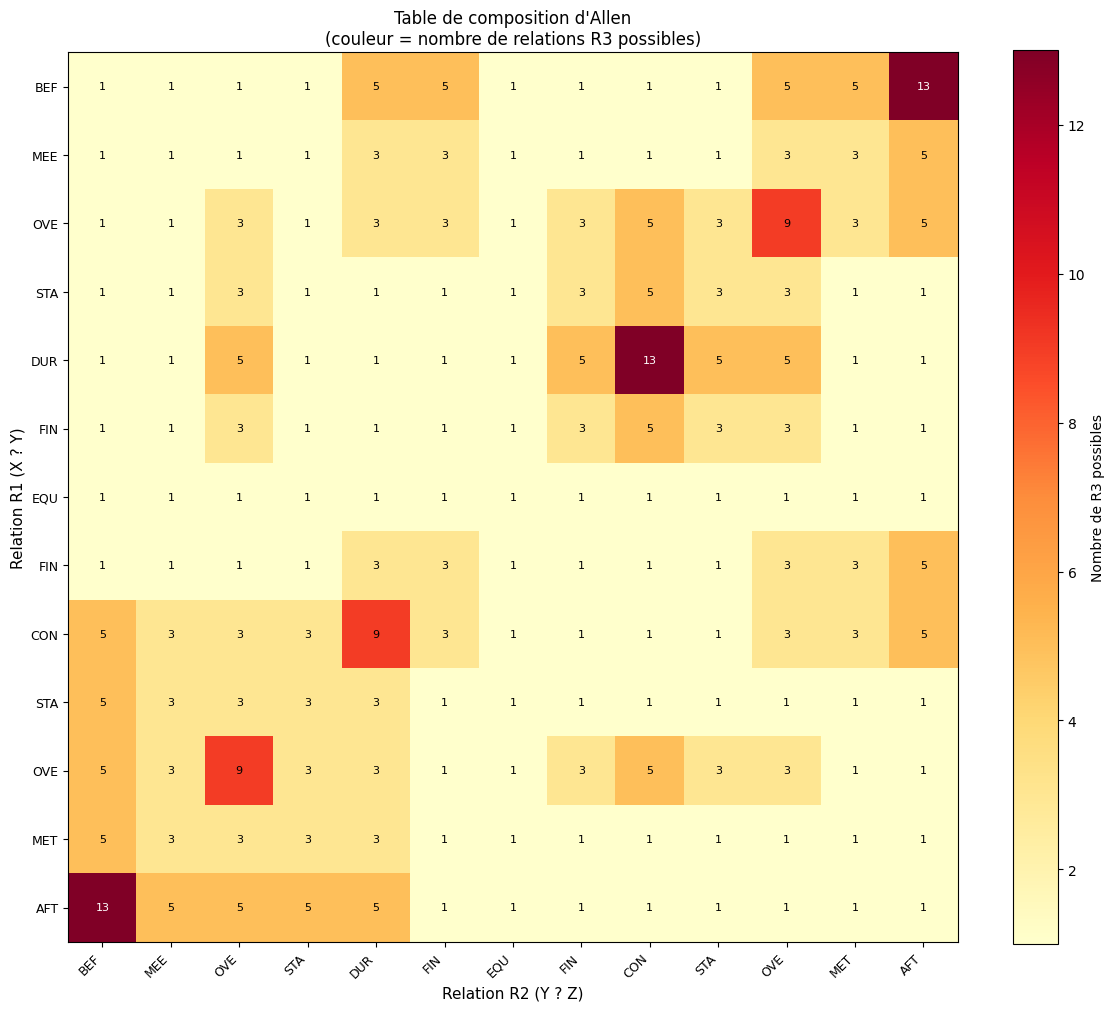

=== Exemples de compositions ===
  BEFORE          o BEFORE          => ['BEFORE']
  OVERLAPS        o OVERLAPS        => ['BEFORE', 'MEETS', 'OVERLAPS']
  DURING          o CONTAINS        => ['AFTER', 'BEFORE', 'CONTAINS', 'DURING', 'EQUALS', 'FINISHED_BY', 'FINISHES', 'MEETS', 'MET_BY', 'OVERLAPPED_BY', 'OVERLAPS', 'STARTED_BY', 'STARTS']
  MEETS           o OVERLAPS        => ['BEFORE']
  STARTS          o FINISHES        => ['DURING']


In [23]:

def plot_composition_table(table: Dict):
    rels = list(AllenRelation)
    n = len(rels)
    names = [r.name[:3] for r in rels]

    matrix = np.zeros((n, n), dtype=int)
    for i, r1 in enumerate(rels):
        for j, r2 in enumerate(rels):
            matrix[i, j] = len(table[(r1, r2)])

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=1, vmax=13)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Relation R2 (Y ? Z)", fontsize=11)
    ax.set_ylabel("Relation R1 (X ? Y)", fontsize=11)
    ax.set_title("Table de composition d'Allen\n(couleur = nombre de relations R3 possibles)", fontsize=12)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                    fontsize=8, color='black' if matrix[i, j] < 10 else 'white')

    plt.colorbar(im, ax=ax, label="Nombre de R3 possibles")
    plt.tight_layout()
    plt.show()

    print("=== Exemples de compositions ===")
    examples = [
        (AllenRelation.BEFORE,   AllenRelation.BEFORE),
        (AllenRelation.OVERLAPS, AllenRelation.OVERLAPS),
        (AllenRelation.DURING,   AllenRelation.CONTAINS),
        (AllenRelation.MEETS,    AllenRelation.OVERLAPS),
        (AllenRelation.STARTS,   AllenRelation.FINISHES),
    ]
    for r1, r2 in examples:
        result_names = sorted(r.name for r in table[(r1, r2)])
        print(f"  {r1.name:15s} o {r2.name:15s} => {result_names}")

plot_composition_table(FULL_COMPOSITION)

In [24]:
# Exercice 4 : STP avec OR-Tools CP-SAT
install_if_missing('ortools')
from ortools.sat.python import cp_model


# Exercice 4 : Template - STP avec OR-Tools
def solve_stp_cp_sat(constraints: List[Tuple[str, str, float, float]]) -> Dict[str, int]:
    """
    TODO: Implementez un STP avec OR-Tools CP-SAT.
    
    Args:
        constraints: Liste de (i, j, lb, ub) signifiant lb <= t_j - t_i <= ub
    
    Returns:
        Dictionnaire point -> temps, ou {} si inconsistent
    """
    points = sorted({p for c in constraints for p in (c[0], c[1])})

    model = cp_model.CpModel()
    t = {p: model.NewIntVar(0, 10000, f"t_{p}") for p in points}

    ref = ("T0" if "T0" in t else points[0])
    model.Add(t[ref] == 0)

    for (i, j, lb, ub) in constraints:
        lb_i, ub_i = int(round(lb)), int(round(ub))
        if lb_i > ub_i:
            return {} 
        model.Add(t[j] - t[i] >= lb_i)
        model.Add(t[j] - t[i] <= ub_i)

    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {p: solver.Value(v) for p, v in t.items()}
    return {}


constraints_min = [('T0', 'T1', 8, 9), ('T0', 'T2', 10, 11)]
print(f"Solution CP-SAT : {solve_stp_cp_sat(constraints_min)}")


Solution CP-SAT : {'T0': 0, 'T1': 8, 'T2': 10}


---

## References

1. **Allen's Interval Algebra** : J.F. Allen (1983) - "Maintaining Knowledge about Temporal Intervals"
2. **STP/TCSP** : Dechter, Meiri, Pearl (1991) - "Temporal Constraint Networks" (AIJ Classic Paper Award 2020)
3. **Dechter (2003)** : Chapitre "Temporal Reasoning" dans Constraint Processing
4. **Path Consistency** : Algorithmes PC-1, PC-2 pour propagation temporelle

### Navigation

- [<< Search-16 CSP-Soft](Search-16-CSP-Soft.ipynb)
- [Index](../README.md)
- [Search-18 CSP-Distributed >>](Search-18-CSP-Distributed.ipynb)